# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [69]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [70]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

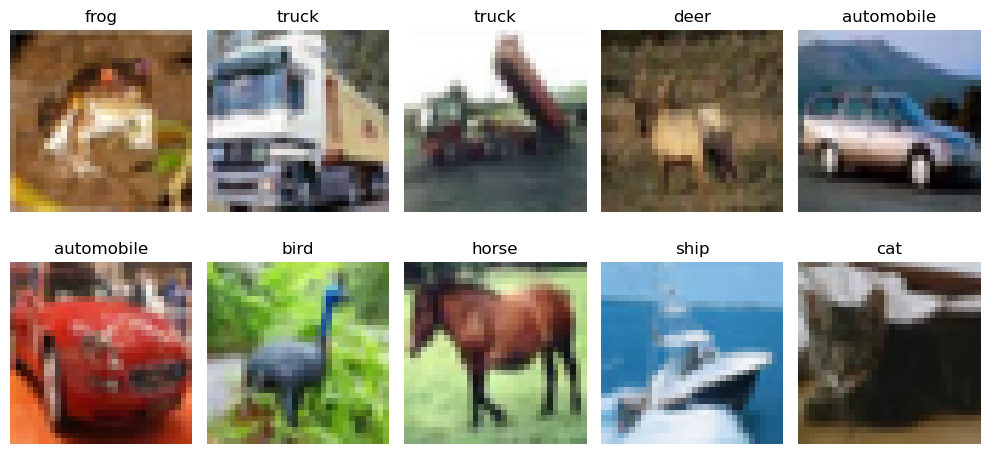

In [71]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [72]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [73]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.2652 - loss: 2.0027 - val_accuracy: 0.3442 - val_loss: 1.8442
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3111 - loss: 1.8764 - val_accuracy: 0.3496 - val_loss: 1.7938
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3294 - loss: 1.8235 - val_accuracy: 0.3604 - val_loss: 1.7825
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3471 - loss: 1.7875 - val_accuracy: 0.3822 - val_loss: 1.7413
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3559 - loss: 1.7681 - val_accuracy: 0.3932 - val_loss: 1.7218
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3640 - loss: 1.7479 - val_accuracy: 0.3970 - val_loss: 1.6938
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3682 - loss: 1.7338 - val_accuracy: 0.4122 - val_loss: 1.6717
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3781 - loss: 1.7122 - 

In [74]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4371 - loss: 1.6319 
ANN Test Accuracy: 0.43709999322891235


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [75]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 75ms/step - accuracy: 0.4658 - loss: 1.4835 - val_accuracy: 0.4776 - val_loss: 1.5229
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.6116 - loss: 1.1056 - val_accuracy: 0.6344 - val_loss: 1.0423
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.6732 - loss: 0.9368 - val_accuracy: 0.6294 - val_loss: 1.0823
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7159 - loss: 0.8135 - val_accuracy: 0.6992 - val_loss: 0.8633
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7440 - loss: 0.7290 - val_accuracy: 0.6932 - val_loss: 0.9002
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7746 - loss: 0.6399 - val_accuracy: 0.7266 - val_loss: 0.8358
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.7939 - loss: 0.5814 - val_accuracy: 0.6010 - val_loss: 1.2499
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.8153 - loss: 0.5211 - 

In [76]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7232 - loss: 0.9590
CNN Test Accuracy: 0.7232000231742859


## 📈 Compare Learning Curves

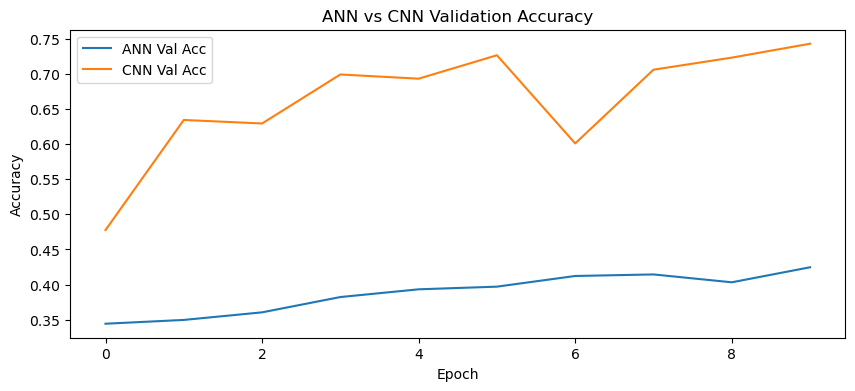

In [77]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [78]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [79]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4371
1,CNN,0.7232


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

##Impplementation of Student WORK:##

**1.) Increase ANN layers and observe performance** 


Original Code:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Here accuracy was: 0.4298

The flow was :
3072 → 512 → 256 → 10

**Increasing ANN layerings**
2.) **using *3072 → 512 → 256 → 128 → 10***

In [80]:
ann_model_2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_2 = ann_model_2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.2687 - loss: 1.9862 - val_accuracy: 0.3068 - val_loss: 1.8620
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3154 - loss: 1.8679 - val_accuracy: 0.3474 - val_loss: 1.8032
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3302 - loss: 1.8237 - val_accuracy: 0.3506 - val_loss: 1.7884
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3442 - loss: 1.7860 - val_accuracy: 0.3874 - val_loss: 1.7139
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3553 - loss: 1.7633 - val_accuracy: 0.3978 - val_loss: 1.7250
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3671 - loss: 1.7365 - val_accuracy: 0.4006 - val_loss: 1.7070
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3780 - loss: 1.7117 - val_accuracy: 0.4014 - val_loss: 1.6627
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.3870 - loss: 1.6919 - 

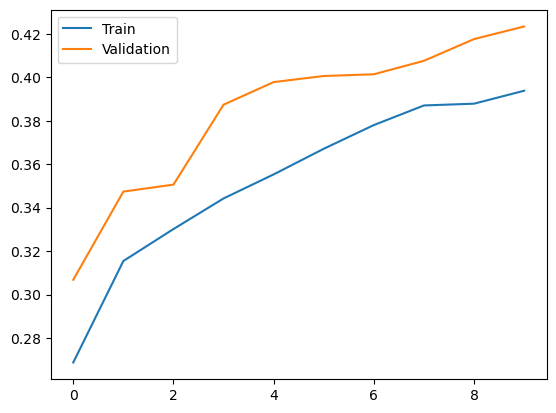

In [81]:
plt.plot(ann_history_2.history['accuracy'])
plt.plot(ann_history_2.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

3.) **using *3072 → 1024 → 512 → 256 → 128 → 10***

In [82]:
ann_model_3 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_3 = ann_model_3.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.2539 - loss: 2.0119 - val_accuracy: 0.3068 - val_loss: 1.9059
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3091 - loss: 1.8804 - val_accuracy: 0.3302 - val_loss: 1.8373
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.3314 - loss: 1.8319 - val_accuracy: 0.3572 - val_loss: 1.7711
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.3452 - loss: 1.7975 - val_accuracy: 0.3884 - val_loss: 1.7235
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3623 - loss: 1.7633 - val_accuracy: 0.3764 - val_loss: 1.7360
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.3681 - loss: 1.7477 - val_accuracy: 0.3878 - val_loss: 1.7195
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3747 - loss: 1.7242 - val_accuracy: 0.4106 - val_loss: 1.6745
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3819 - loss: 1.7111 - 

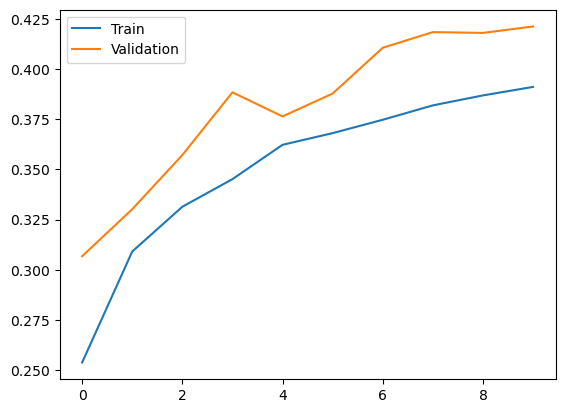

In [83]:
plt.plot(ann_history_3.history['accuracy'])
plt.plot(ann_history_3.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

4.) **using *3072 → 1024 → 512 → 256 → 128 → 64 → 32 → 10***

In [84]:
ann_model_4 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(32, activation='relu'),

    layers.Dense(10, activation='softmax')
])
ann_model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_4 = ann_model_4.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.2254 - loss: 2.0489 - val_accuracy: 0.3186 - val_loss: 1.8844
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.3064 - loss: 1.8916 - val_accuracy: 0.3398 - val_loss: 1.8200
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.3245 - loss: 1.8526 - val_accuracy: 0.3554 - val_loss: 1.8092
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.3394 - loss: 1.8080 - val_accuracy: 0.3524 - val_loss: 1.8033
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3502 - loss: 1.7797 - val_accuracy: 0.3706 - val_loss: 1.7285
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.3629 - loss: 1.7536 - val_accuracy: 0.4026 - val_loss: 1.6919
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3692 - loss: 1.7352 - val_accuracy: 0.3904 - val_loss: 1.7051
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.3826 - loss: 1.7103 - 

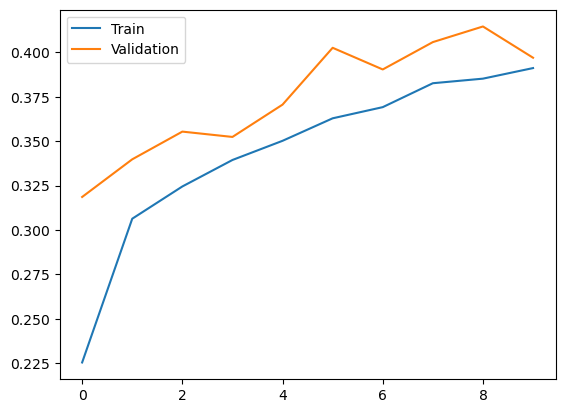

In [85]:
plt.plot(ann_history_4.history['accuracy'])
plt.plot(ann_history_4.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

5.) **using *3072 → 1024 → 512 → 256 → 128 → 64 → 10
(BatchNorm after 1024 and 512 layers)*** 

In [86]:
ann_model_5 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_5 = ann_model_5.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.3438 - loss: 1.8188 - val_accuracy: 0.3352 - val_loss: 1.8710
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.3990 - loss: 1.6691 - val_accuracy: 0.3320 - val_loss: 1.8433
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.4157 - loss: 1.6279 - val_accuracy: 0.3682 - val_loss: 1.7353
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.4250 - loss: 1.6040 - val_accuracy: 0.4214 - val_loss: 1.6221
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.4364 - loss: 1.5699 - val_accuracy: 0.4558 - val_loss: 1.5450
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.4459 - loss: 1.5471 - val_accuracy: 0.4452 - val_loss: 1.5680
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.4508 - loss: 1.5320 - val_accuracy: 0.4486 - val_loss: 1.5544
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.4560 - loss: 1.5223 - 

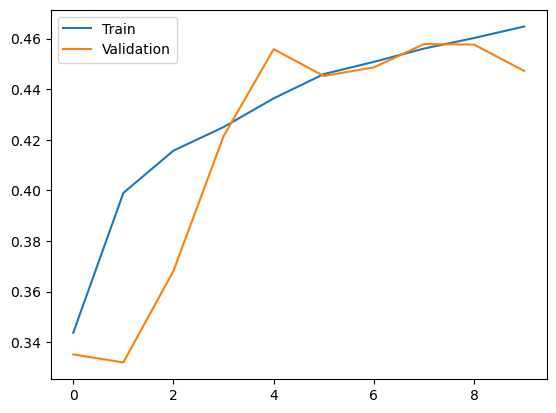

In [87]:
plt.plot(ann_history_5.history['accuracy'])
plt.plot(ann_history_5.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

*Let's See all accuracy scores:*

In [88]:
ann_test_loss_2, ann_test_acc_2 = ann_model_2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased (2.):", ann_test_acc_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4307 - loss: 1.6136 
ANN Test Accuracy For layering increased (2.): 0.43070000410079956


In [89]:
ann_test_loss_3, ann_test_acc_3 = ann_model_3.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased (3.):", ann_test_acc_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4368 - loss: 1.6258
ANN Test Accuracy For layering increased (3.): 0.4368000030517578


In [90]:
ann_test_loss_4, ann_test_acc_4 = ann_model_4.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased (4.):", ann_test_acc_4)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4042 - loss: 1.6754
ANN Test Accuracy For layering increased (4.): 0.4041999876499176


In [91]:
ann_test_loss_5, ann_test_acc_5 = ann_model_5.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased (5.):", ann_test_acc_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4500 - loss: 1.5332
ANN Test Accuracy For layering increased (5.): 0.44999998807907104


In [92]:
from sklearn.metrics import classification_report             #Given earliest

pred = ann_model.predict(x_test_flat)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       0.58      0.40      0.47      1000
           1       0.53      0.56      0.54      1000
           2       0.37      0.19      0.25      1000
           3       0.27      0.24      0.26      1000
           4       0.36      0.37      0.37      1000
           5       0.41      0.36      0.38      1000
           6       0.37      0.63      0.47      1000
           7       0.54      0.45      0.49      1000
           8       0.55      0.57      0.56      1000
           9       0.43      0.60      0.50      1000

    accuracy                           0.44     10000
   macro avg       0.44      0.44      0.43     10000
weighted avg       0.44      0.44      0.43     10000



In [93]:
from sklearn.metrics import classification_report

pred = ann_model_2.predict(x_test_flat)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

           0       0.57      0.44      0.50      1000
           1       0.61      0.52      0.56      1000
           2       0.28      0.38      0.32      1000
           3       0.27      0.20      0.23      1000
           4       0.37      0.29      0.33      1000
           5       0.46      0.27      0.34      1000
           6       0.35      0.74      0.47      1000
           7       0.55      0.37      0.44      1000
           8       0.52      0.64      0.57      1000
           9       0.53      0.46      0.50      1000

    accuracy                           0.43     10000
   macro avg       0.45      0.43      0.43     10000
weighted avg       0.45      0.43      0.43     10000



In [94]:

pred = ann_model_3.predict(x_test_flat)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

           0       0.57      0.44      0.50      1000
           1       0.46      0.69      0.55      1000
           2       0.33      0.24      0.28      1000
           3       0.32      0.39      0.35      1000
           4       0.38      0.29      0.33      1000
           5       0.56      0.14      0.22      1000
           6       0.37      0.70      0.48      1000
           7       0.53      0.45      0.49      1000
           8       0.62      0.51      0.56      1000
           9       0.44      0.52      0.48      1000

    accuracy                           0.44     10000
   macro avg       0.46      0.44      0.42     10000
weighted avg       0.46      0.44      0.42     10000



In [95]:

pred = ann_model_4.predict(x_test_flat)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 
              precision    recall  f1-score   support

           0       0.54      0.41      0.47      1000
           1       0.62      0.30      0.41      1000
           2       0.30      0.18      0.22      1000
           3       0.23      0.31      0.26      1000
           4       0.34      0.41      0.37      1000
           5       0.33      0.41      0.36      1000
           6       0.43      0.46      0.44      1000
           7       0.48      0.43      0.45      1000
           8       0.57      0.51      0.54      1000
           9       0.41      0.62      0.50      1000

    accuracy                           0.40     10000
   macro avg       0.43      0.40      0.40     10000
weighted avg       0.43      0.40      0.40     10000



In [96]:

pred = ann_model_5.predict(x_test_flat)
pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      1000
           1       0.44      0.70      0.54      1000
           2       0.32      0.37      0.34      1000
           3       0.34      0.34      0.34      1000
           4       0.41      0.39      0.40      1000
           5       0.57      0.15      0.24      1000
           6       0.39      0.60      0.47      1000
           7       0.68      0.36      0.47      1000
           8       0.58      0.57      0.58      1000
           9       0.54      0.48      0.51      1000

    accuracy                           0.45     10000
   macro avg       0.48      0.45      0.44     10000
weighted avg       0.48      0.45      0.44     10000



**2.) Change CNN filters from 32→64→128**

2.) using (Increasing Filters)
*64 → 128 → 256*

In [97]:
cnn_model_2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_2 = cnn_model_2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 158ms/step - accuracy: 0.4561 - loss: 1.5277 - val_accuracy: 0.5442 - val_loss: 1.3008
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.6038 - loss: 1.1387 - val_accuracy: 0.5180 - val_loss: 1.3888
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 157ms/step - accuracy: 0.6701 - loss: 0.9569 - val_accuracy: 0.5964 - val_loss: 1.1868
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 157ms/step - accuracy: 0.7171 - loss: 0.8146 - val_accuracy: 0.6524 - val_loss: 1.0617
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 109s 155ms/step - accuracy: 0.7519 - loss: 0.7125 - val_accuracy: 0.6240 - val_loss: 1.0842
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 156ms/step - accuracy: 0.7853 - loss: 0.6099 - val_accuracy: 0.6582 - val_loss: 1.0544
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.8095 - loss: 0.5357 - val_accuracy: 0.7166 - val_loss: 0.9041
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 109s 155ms/step - accuracy: 0.8378 -

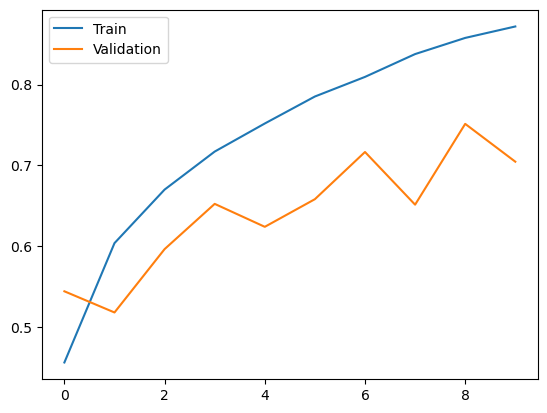

In [98]:
plt.plot(cnn_history_2.history['accuracy'])
plt.plot(cnn_history_2.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

3.) Deeper feature Extraction
*32 → 32 → 64 → 64 → 128*

In [99]:
cnn_model_3 = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu',
                  padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])
cnn_model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_3 = cnn_model_3.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 197ms/step - accuracy: 0.4487 - loss: 1.5423 - val_accuracy: 0.5956 - val_loss: 1.1684
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 208ms/step - accuracy: 0.6163 - loss: 1.0936 - val_accuracy: 0.6850 - val_loss: 0.8929
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 222ms/step - accuracy: 0.6922 - loss: 0.8887 - val_accuracy: 0.7154 - val_loss: 0.8349
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 214ms/step - accuracy: 0.7355 - loss: 0.7673 - val_accuracy: 0.7640 - val_loss: 0.6828
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 219ms/step - accuracy: 0.7665 - loss: 0.6802 - val_accuracy: 0.7560 - val_loss: 0.7235
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 216ms/step - accuracy: 0.7893 - loss: 0.5991 - val_accuracy: 0.7648 - val_loss: 0.7231
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 212ms/step - accuracy: 0.8161 - loss: 0.5319 - val_accuracy: 0.6982 - val_loss: 0.9461
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.8304 -

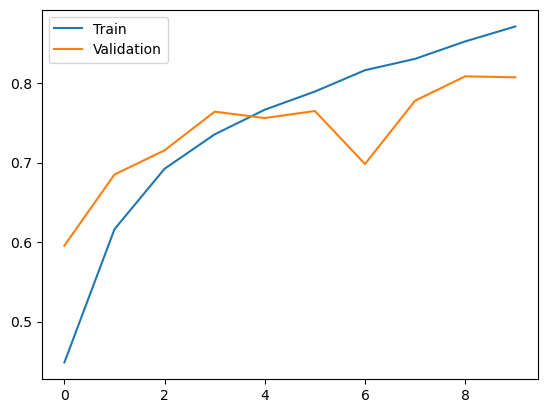

In [100]:
plt.plot(cnn_history_3.history['accuracy'])
plt.plot(cnn_history_3.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

4.) High Capacity Model
*64 → 64 → 128 → 128 → 256*

In [101]:
cnn_model_5 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

cnn_model_5.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_5 = cnn_model_5.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 452s 627ms/step - accuracy: 0.4219 - loss: 1.6035 - val_accuracy: 0.5236 - val_loss: 1.3207
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 462s 656ms/step - accuracy: 0.5738 - loss: 1.1877 - val_accuracy: 0.6072 - val_loss: 1.1204
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 461s 654ms/step - accuracy: 0.6389 - loss: 1.0126 - val_accuracy: 0.6840 - val_loss: 0.9210
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 454s 644ms/step - accuracy: 0.6848 - loss: 0.9001 - val_accuracy: 0.6672 - val_loss: 1.0474
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 174s 247ms/step - accuracy: 0.7120 - loss: 0.8262 - val_accuracy: 0.6876 - val_loss: 0.9080
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 174s 247ms/step - accuracy: 0.7320 - loss: 0.7690 - val_accuracy: 0.7052 - val_loss: 0.8676
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 173s 246ms/step - accuracy: 0.7508 - loss: 0.7157 - val_accuracy: 0.7554 - val_loss: 0.7158
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 176s 249ms/step - accuracy: 0.7652 -

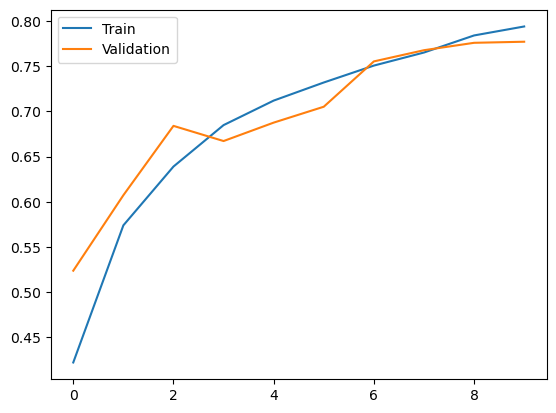

In [102]:
plt.plot(cnn_history_5.history['accuracy'])
plt.plot(cnn_history_5.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

In [103]:
cnn_test_loss_2, cnn_test_acc_2 = cnn_model_2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7026 - loss: 1.0523
CNN Test Accuracy: 0.7026000022888184


In [104]:
cnn_test_loss_3, cnn_test_acc_3 = cnn_model_3.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7977 - loss: 0.6705
CNN Test Accuracy: 0.7976999878883362


In [105]:
cnn_test_loss_5, cnn_test_acc_5 = cnn_model_5.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7649 - loss: 0.7061
CNN Test Accuracy: 0.7649000287055969


##Increasing Epoche from 10 to 20

*ANN*

In [106]:
ann_model_2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_20 = ann_model_2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2720 - loss: 1.9814 - val_accuracy: 0.3418 - val_loss: 1.8345
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3248 - loss: 1.8502 - val_accuracy: 0.3766 - val_loss: 1.7510
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3457 - loss: 1.7947 - val_accuracy: 0.3722 - val_loss: 1.7586
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3620 - loss: 1.7567 - val_accuracy: 0.3724 - val_loss: 1.7459
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3707 - loss: 1.7317 - val_accuracy: 0.4068 - val_loss: 1.6684
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3801 - loss: 1.7126 - val_accuracy: 0.4094 - val_loss: 1.6706
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3851 - loss: 1.6923 - val_accuracy: 0.4142 - val_loss: 1.6584
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3939 - loss: 1.6716 - 

In [107]:
ann_test_loss_20, ann_test_acc_20 = ann_model_2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased (2.):", ann_test_acc_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4586 - loss: 1.5425 
ANN Test Accuracy For layering increased (2.): 0.4586000144481659


*CNN*

In [108]:
cnn_model_2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_20 = cnn_model_2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 87ms/step - accuracy: 0.4370 - loss: 1.5707 - val_accuracy: 0.4358 - val_loss: 1.5274
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5929 - loss: 1.1662 - val_accuracy: 0.5098 - val_loss: 1.5678
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.6656 - loss: 0.9620 - val_accuracy: 0.6228 - val_loss: 1.1119
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7151 - loss: 0.8233 - val_accuracy: 0.5690 - val_loss: 1.3026
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7530 - loss: 0.7121 - val_accuracy: 0.7126 - val_loss: 0.8449
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7905 - loss: 0.6086 - val_accuracy: 0.6620 - val_loss: 1.1514
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.8164 - loss: 0.5266 - val_accuracy: 0.7242 - val_loss: 0.9288
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.8390 - loss: 0.4550 - 

In [109]:
cnn_test_loss_20, cnn_test_acc_20 = cnn_model_3.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_20)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7977 - loss: 0.6705
CNN Test Accuracy: 0.7976999878883362


In [110]:
cnn_history_20.history.keys()



dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [111]:
print(cnn_history_20.history['accuracy'])
print(cnn_history.history['val_accuracy'])

[0.46577778458595276, 0.6115999817848206, 0.6731555461883545, 0.7159110903739929, 0.7439555525779724, 0.7745555639266968, 0.7938888669013977, 0.8152889013290405, 0.8310444355010986, 0.8487333059310913]
[0.47760000824928284, 0.6344000101089478, 0.6294000148773193, 0.6991999745368958, 0.6931999921798706, 0.7265999913215637, 0.6010000109672546, 0.7059999704360962, 0.7232000231742859, 0.7429999709129333]


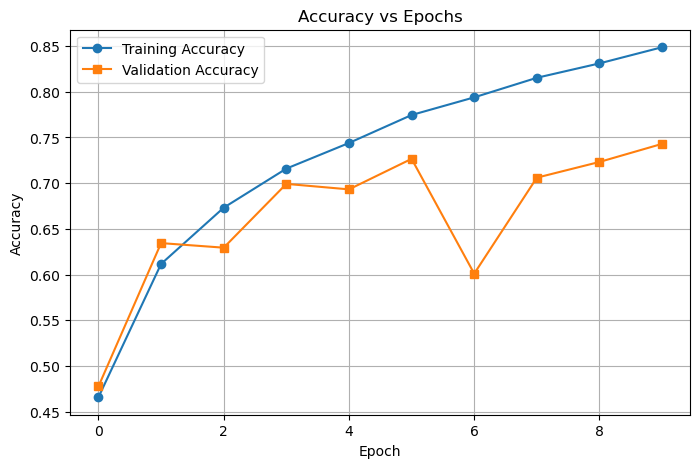

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    cnn_history_20.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    cnn_history_20.history['val_accuracy'],
    marker='s',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.show()

4.) Using EarlyStopping

a]CNN

In [113]:
from tensorflow.keras.callbacks import EarlyStopping
cnn_model_2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history_early = cnn_model_2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 81ms/step - accuracy: 0.4468 - loss: 1.5554 - val_accuracy: 0.5138 - val_loss: 1.3620
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5954 - loss: 1.1598 - val_accuracy: 0.5632 - val_loss: 1.2214
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.6682 - loss: 0.9622 - val_accuracy: 0.6296 - val_loss: 1.0965
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.7189 - loss: 0.8176 - val_accuracy: 0.6248 - val_loss: 1.1261
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.7550 - loss: 0.7104 - val_accuracy: 0.6320 - val_loss: 1.0965
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.7873 - loss: 0.6108 - val_accuracy: 0.6040 - val_loss: 1.2659
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.8137 - loss: 0.5310 - val_accuracy: 0.7474 - val_loss: 0.7645
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.8388 - loss: 0.4566 - 

In [114]:
cnn_test_loss_early, cnn_test_acc_early = cnn_model_2.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_early)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7225 - loss: 1.4177
CNN Test Accuracy: 0.7225000262260437


b]ANN

In [115]:
ann_model_2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
ann_history_early = ann_model_2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.2734 - loss: 1.9791 - val_accuracy: 0.3420 - val_loss: 1.8275
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3346 - loss: 1.8302 - val_accuracy: 0.3834 - val_loss: 1.7269
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3541 - loss: 1.7760 - val_accuracy: 0.3950 - val_loss: 1.7106
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3706 - loss: 1.7318 - val_accuracy: 0.3942 - val_loss: 1.7008
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3821 - loss: 1.7091 - val_accuracy: 0.3964 - val_loss: 1.6655
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3930 - loss: 1.6806 - val_accuracy: 0.4014 - val_loss: 1.6700
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4036 - loss: 1.6575 - val_accuracy: 0.4164 - val_loss: 1.6560
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4073 - loss: 1.6454 - 

In [116]:
ann_test_loss_early, ann_test_acc_early = ann_model_2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy For layering increased :", ann_test_acc_early)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4722 - loss: 1.5123  
ANN Test Accuracy For layering increased : 0.4722000062465668


5.) Data Augmentation + Earlystopping

In [117]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([

    # Data Augmentation Layer
    data_augmentation,

    # CNN Block 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2,2)),

    # CNN Block 3
    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.4863 - loss: 1.4264 - val_accuracy: 0.5710 - val_loss: 1.1999
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.5548 - loss: 1.2602 - val_accuracy: 0.5088 - val_loss: 1.5053
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.5955 - loss: 1.1551 - val_accuracy: 0.5924 - val_loss: 1.1760
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6301 - loss: 1.0651 - val_accuracy: 0.6488 - val_loss: 1.0405
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.6558 - loss: 1.0045 - val_accuracy: 0.6768 - val_loss: 0.9738
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6748 - loss: 0.9475 - val_accuracy: 0.7242 - val_loss: 0.8338
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.6905 - loss: 0.9072 - val_accuracy: 0.7336 - val_loss: 0.7877
Epoch 9/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.7029 - loss: 0.8673 -

In [118]:
cnn_test_loss_aug, cnn_test_acc_aug = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7962 - loss: 0.6089
CNN Test Accuracy: 0.7961999773979187


Comparison:

In [119]:
comparison1 = pd.DataFrame({
    "Model": ["ANN", "ANN-2","ANN-3","ANN-4","ANN-5"],
    "Test Accuracy": [ann_test_acc, ann_test_acc_2,ann_test_acc-3,ann_test_4,ann_test_5]
})
comparison1

NameError: name 'ann_test_3' is not defined

In [ ]:
comparison2 = pd.DataFrame({
    "Model": ["CNN", "CNN-2","CNN-3","CNN-5"],
    "Test Accuracy": [cnn_test_acc, cnn_test_acc_2,cnn_test_3,ann_test_5]
})
comparison2

In [ ]:
comparison3 = pd.DataFrame({
    "Model": ["ANN-2","ANN-earlystoping","ANN-epoche20"],
    "Test Accuracy": [ann_test_acc_2,ann_test_acc_early, ann_test_acc_20,]
})
comparison3

In [ ]:
comparison4 = pd.DataFrame({
    "Model": ["ANN-2","ANN-earlystopping","CNN-epoche-20"],
    "Test Accuracy": [ann_test_acc_2, ann_test_acc_early,ann_test_acc_20]
})
comparison4